# Benchmark v2 — the conclusive story
### Heteroscedastic mixed-variable BO: which surrogate gives the best *and most robust* designs?

A curated companion to `compare.ipynb`: only the most conclusive views, organized as a narrative,
with the equations behind every metric and explicit observation/conclusion notes grounded in the
current data. (The full exploratory plot zoo stays in `compare.ipynb`.)

**The story**
1. **The question & the data** — what is being compared, on how much evidence.
2. **The answer key** — ground truth: where the optima are, and which problems truly test robustness.
3. **Optimization performance** — who finds good designs fastest (regret), and its honest caveat.
4. **Model quality** — who *models* best: accuracy, calibration, noise capture (loop-free).
5. **Robustness** — who *recommends* robust designs: Pareto, percentiles, MV.
6. **Cost** — what each model charges for its answers.
7. **Verdict** — what we can and cannot conclude today.

*Models*: Separate GP · Categorical kernel · Standard LVGP · **Heteroscedastic LVGP (ours)** —
*Acquisitions*: EI/LCB/PI (noise-blind) + HAEI/ANPEI/RAHBO (noise-aware).
> Conclusions below reflect the data as of **2026-07-21** (6 problems complete; piston/rastrigin
> filling; 10-D pending). Re-run to refresh.

## §1 — The question & the data

**What/Why:** load every stored result cell; count the evidence. All analysis derives from stored
`.npz`/`.mat` cells — nothing is re-run. The aux python-LVGP validation models are excluded
(they live in `compare_matlab_python.ipynb`).

**How:** `GridResults` loads the schema-v2 cells; `DONE` = problems with the full
4-models × 6-acqs × 2-nreps × 5-seeds block, the only ones the conclusion cells use.

In [1]:
%load_ext autoreload
%autoreload 2
import warnings; warnings.filterwarnings("ignore")
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, matplotlib.pyplot as plt
from utils import problems as P
from utils.results import (GridResults, style_best, regret_heatmap, final_regret_table,
                           method_ranking, runtime_table, model_quality_table, model_quality_ranks,
                           design_robustness_table, mv_optima_table, mv_landscape,
                           pareto_plot, percentile_framing, quantile_landscape, mv_alpha_sweep,
                           acq_method_table, style_best_combined)
from utils.models import MODELS as _M

grid = GridResults.load('../results')
grid = GridResults(grid.root, [r for r in grid.runs if not _M[r['model']].aux])
N_REP, SEEDS = 10, 5
FUNCS = grid.functions()
ONE_D = [f for f in FUNCS if P.get(f).d == 1]
DONE  = [f for f in FUNCS if f in ('ackley_2d','branin_hetero','golinski','griewank_2d',
                                   'otl_circuit','sixhump_camel')]
print('problems :', FUNCS)
print('complete :', DONE)
print('models   :', grid.models(), '   cells:', len(grid.runs))

problems : ['ackley_10d', 'ackley_2d', 'branin_hetero', 'golinski', 'griewank_2d', 'otl_circuit', 'piston', 'rastrigin_6d', 'sixhump_camel']
complete : ['ackley_2d', 'branin_hetero', 'golinski', 'griewank_2d', 'otl_circuit', 'sixhump_camel']
models   : ['categorical_kernel', 'heter_LVGP', 'separate_gp', 'standard_LVGP']    cells: 5948


## §2 — The answer key (ground truth, no models involved)

**The two quantities that define every design** $x$ at categorical level $\ell$:
noise-free objective $f(x,\ell)$ and noise variance $\sigma^2(x,\ell)$ (test problems define both
analytically). Robust design means trading them off:

$$\mathrm{MV}_\alpha(x,\ell) = f(x,\ell) + \alpha\,\sigma^2(x,\ell)
\qquad\text{(mean–variance; RAHBO's objective — } \alpha \text{ = risk weight)}$$

**Why first:** before grading models, know the answers — *where* is the nominal optimum
($\arg\min f$), where the robust one ($\arg\min \mathrm{MV}_\alpha$), and on which problems they
differ (only those can separate robust from non-robust methods).

**How to read:** in the table, follow a problem's rows as α grows — a **level/x jump** = a genuine
robustness trap. The landscape (branin as the exemplar) shows the same thing graphically: circle =
per-level optimum, star = global; watch the star change level.

In [2]:
mv_optima_table(functions=DONE)

level       x1     f_true    sigma2         MV
problem       alpha                                                
ackley_2d     0.0        1    0.000     0.0000    0.0100     0.0000
              1.0        1    0.000     0.0000    0.0100     0.0100
              5.0        1    0.000     0.0000    0.0100     0.0500
              15.0       1    0.000     0.0000    0.0100     0.1500
branin_hetero 0.0        2    3.182     0.4651    1.4087     0.4651
              1.0        2    3.145     0.4721    1.3937     1.8658
              5.0        2    3.014     0.6182    1.3439     7.3378
              15.0       4    3.179     5.4499    0.7179    16.2189
golinski      0.0        1    2.600  2352.4478  576.0000  2352.4478
              1.0        1    2.600  2352.4478  576.0000  2928.4478
              5.0        2    2.600  2622.4741  400.0000  4622.4741
              15.0       2    2.600  2622.4741  400.0000  8622.4741
griewank_2d   0.0        1    0.000     0.0000    0.0064     0.0000
              1.0        1    0.000     0.0000    0.0064     0.0064
              5.0        1    0.000     0.0000    0.0064     0.0320
              15.0       2    0.000     0.0619    0.0016     0.0859
otl_circuit   0.0        4  145.215     2.7529    0.0002     2.7529
              1.0        4  145.215     2.7529    0.0002     2.7531
              5.0        4  145.215     2.7529    0.0002     2.7539
              15.0       4  145.215     2.7529    0.0002     2.7559
sixhump_camel 0.0        3   -0.088    -1.0303    0.0056    -1.0303
              1.0        3   -0.088    -1.0303    0.0056    -1.0247
              5.0        3   -0.088    -1.0303    0.0056    -1.0022
              15.0       3   -0.088    -1.0303    0.0056    -0.9458

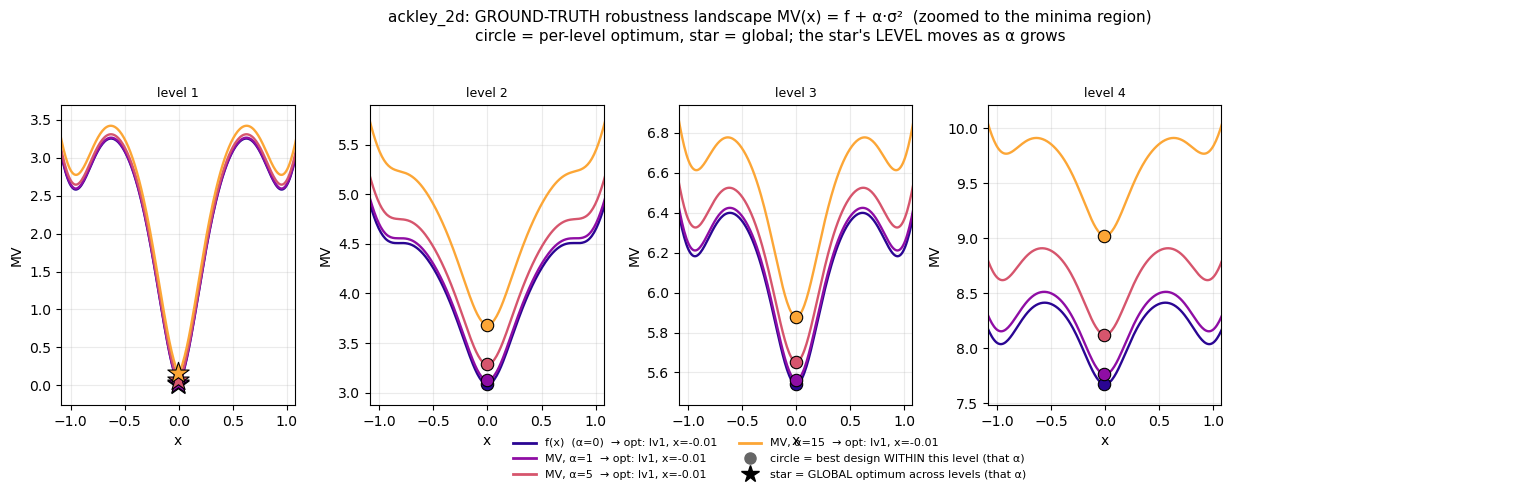

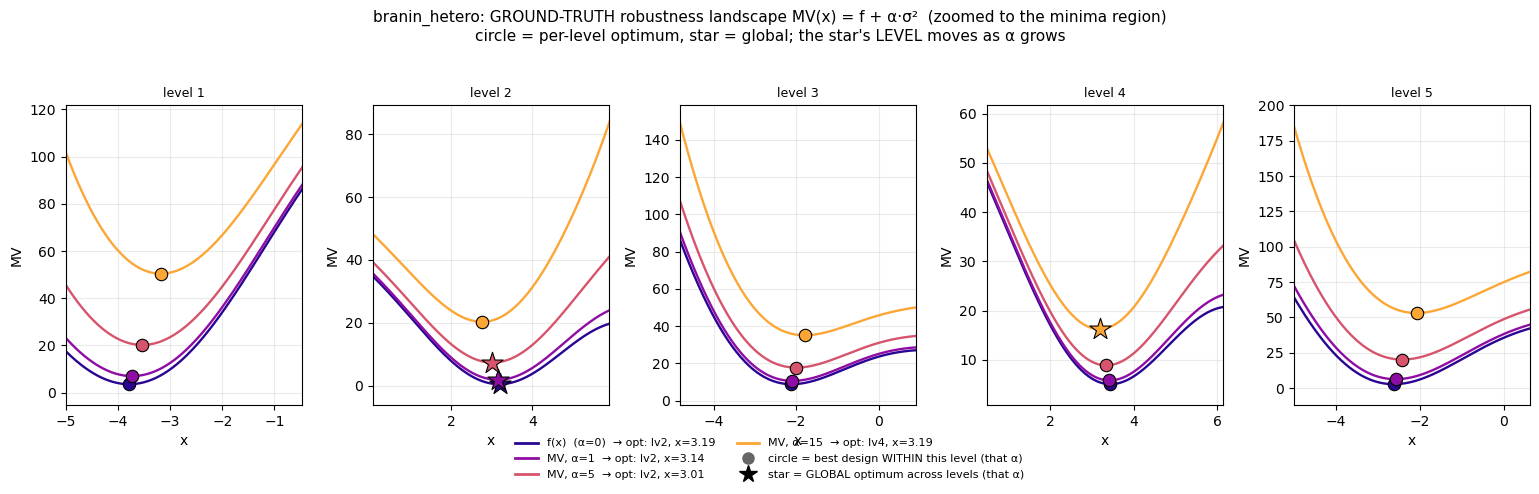

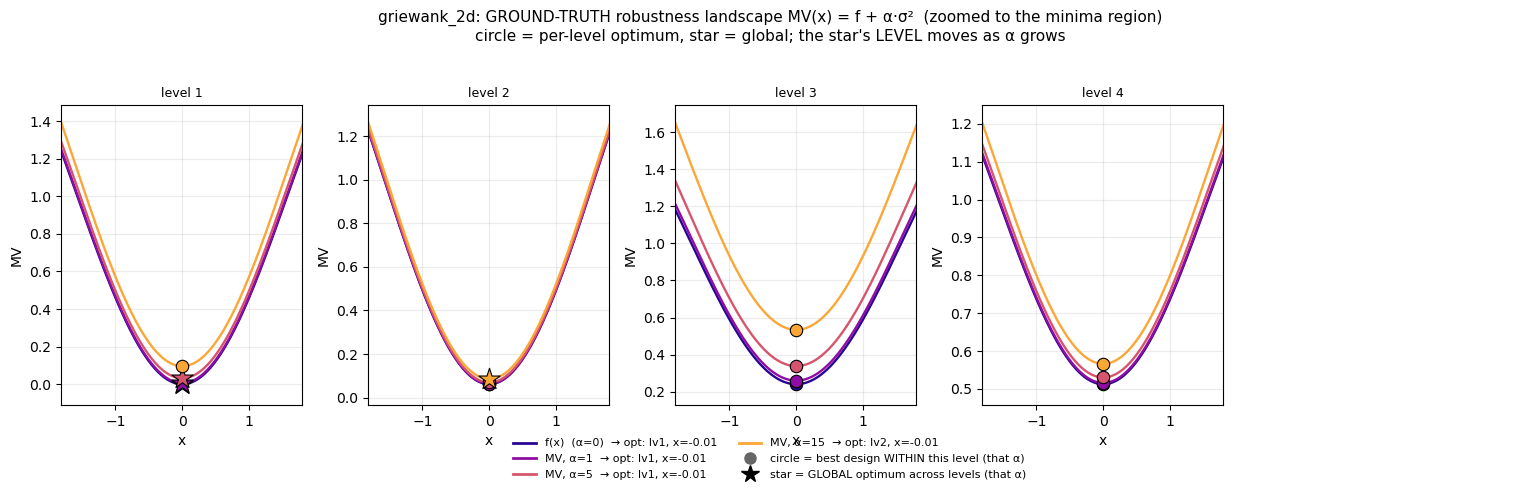

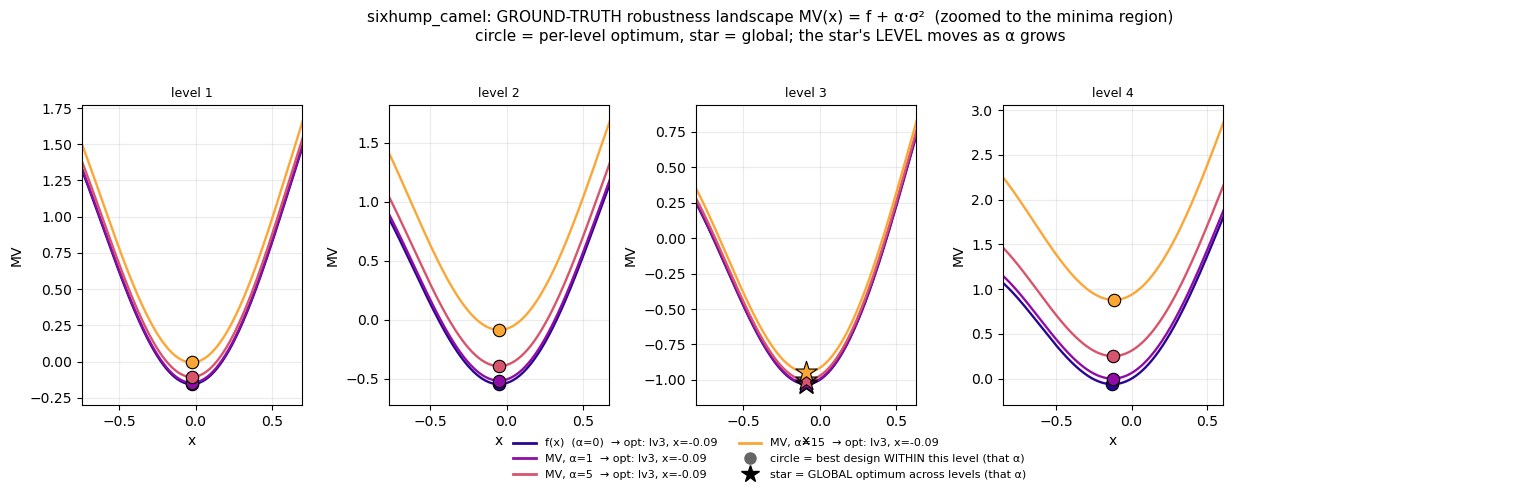

In [3]:
for fn in ONE_D:                      # the four 1-D problems: 2 traps + 2 controls
    mv_landscape(fn);


> **📌 Observations (§2).**
> 1. **Three problems truly test robustness** — the MV optimum *relocates to a different categorical
>    level*: branin lv2→lv4 (α≈7), griewank_2d lv1→lv2 (α≈13), golinski lv1→lv2 (α=5).
> 2. **Two are controls** — camel and ackley's nominal optima are already the quiet ones; every
>    method looks robust there, so they cannot discriminate.
> 3. **The trap is a *category* switch, not an x-shift** (branin keeps x≈3.18) — robustness on this
>    benchmark is a category-identification task, precisely the LVGP latent space's job.
> 4. **The sweep runs RAHBO at α=0.5 — below every threshold**: at that risk weight the robust and
>    nominal optima coincide. Robustness discrimination therefore comes from the α-sweep and the
>    hyperparameter-free views of §5, not from the α=0.5 runs alone.

## §3 — Optimization performance (regret)

**The metric:** after each iteration, the best *noise-free* value of any **sampled** design,
$$\mathrm{regret}(t) = \min_{i \le t} f(x_i) - f^* \qquad (f^* = \text{true optimum; lower = better)}$$
This is `true_best_sampled` — did the method *find* good designs, regardless of what it finally
recommends (recommendation quality is §5's job).

**How to read the heatmap:** final regret, every problem × model × acquisition in one figure
(darker = better). One glance answers "who wins where, under which acquisition".

**⚠ The honest caveat:** the two LVGPs run in MATLAB's BO loop, the two GPs in the python loop, and
the MATLAB loop exploits optima harder (verified on identical models). Cross-**engine** regret gaps
therefore over-credit the MATLAB models; §4's loop-free metrics are the fair model-vs-model view.
Within an engine, regret comparisons are clean.

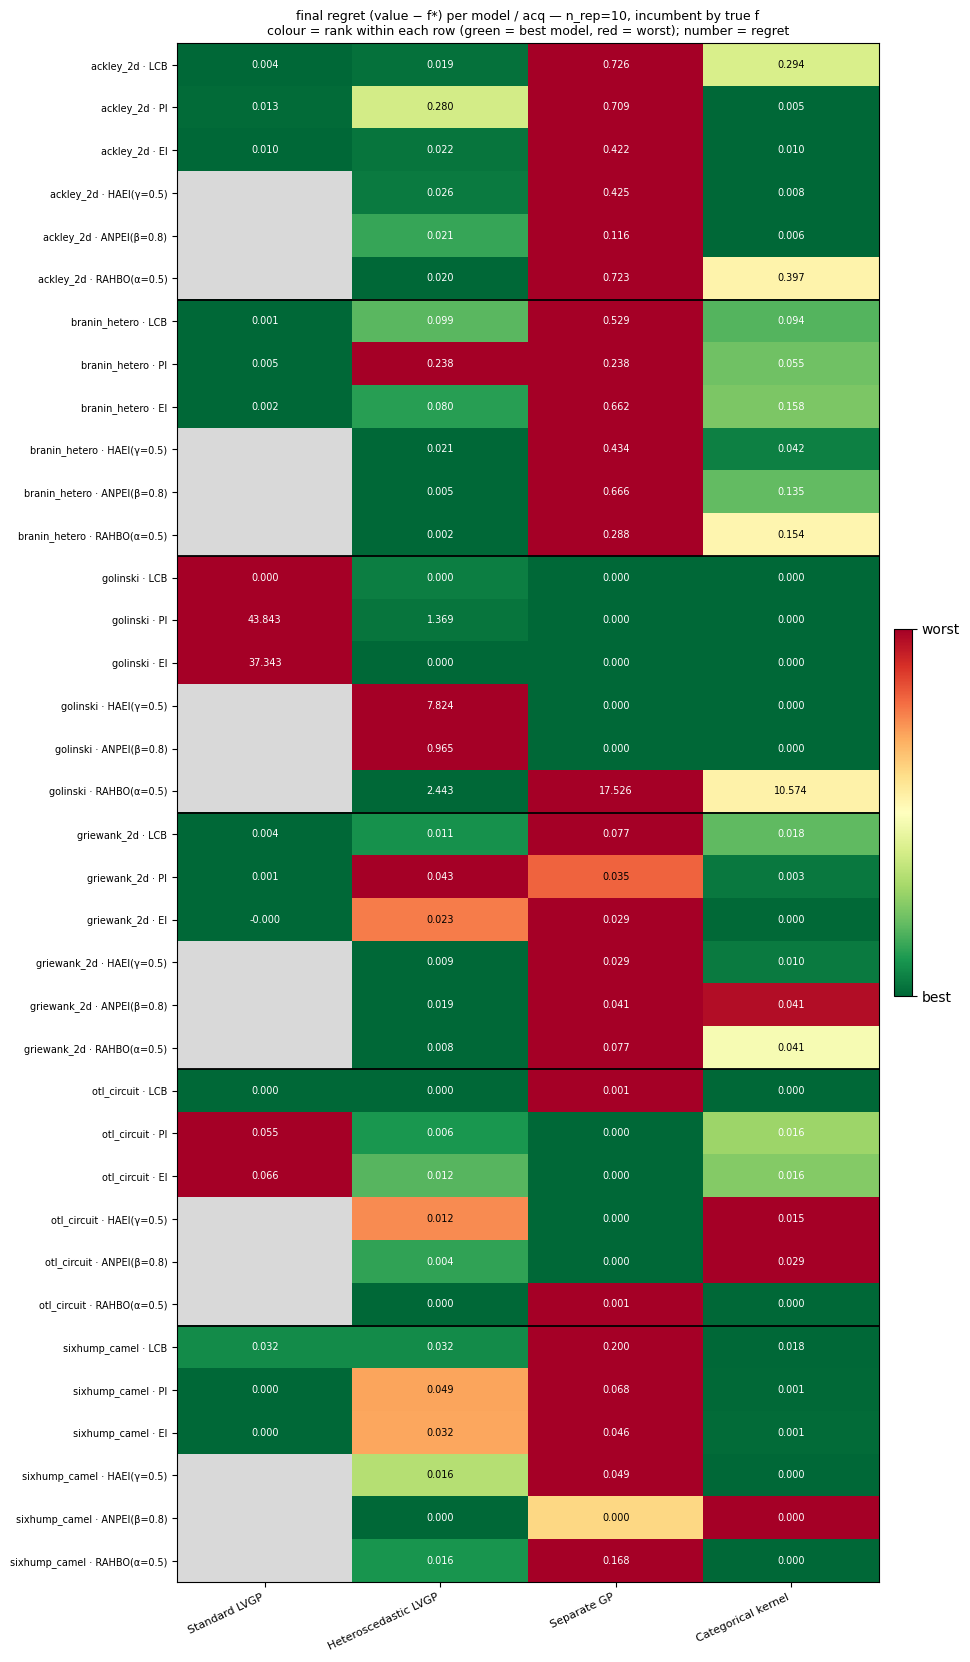

In [4]:
regret_heatmap(grid, functions=DONE, n_rep=N_REP, ground_truth=True);

**Per-problem heatmaps — all problems.** One acquisition × model panel per problem
(including the still-filling ackley_10d, where missing cells show blank). Darker = better.

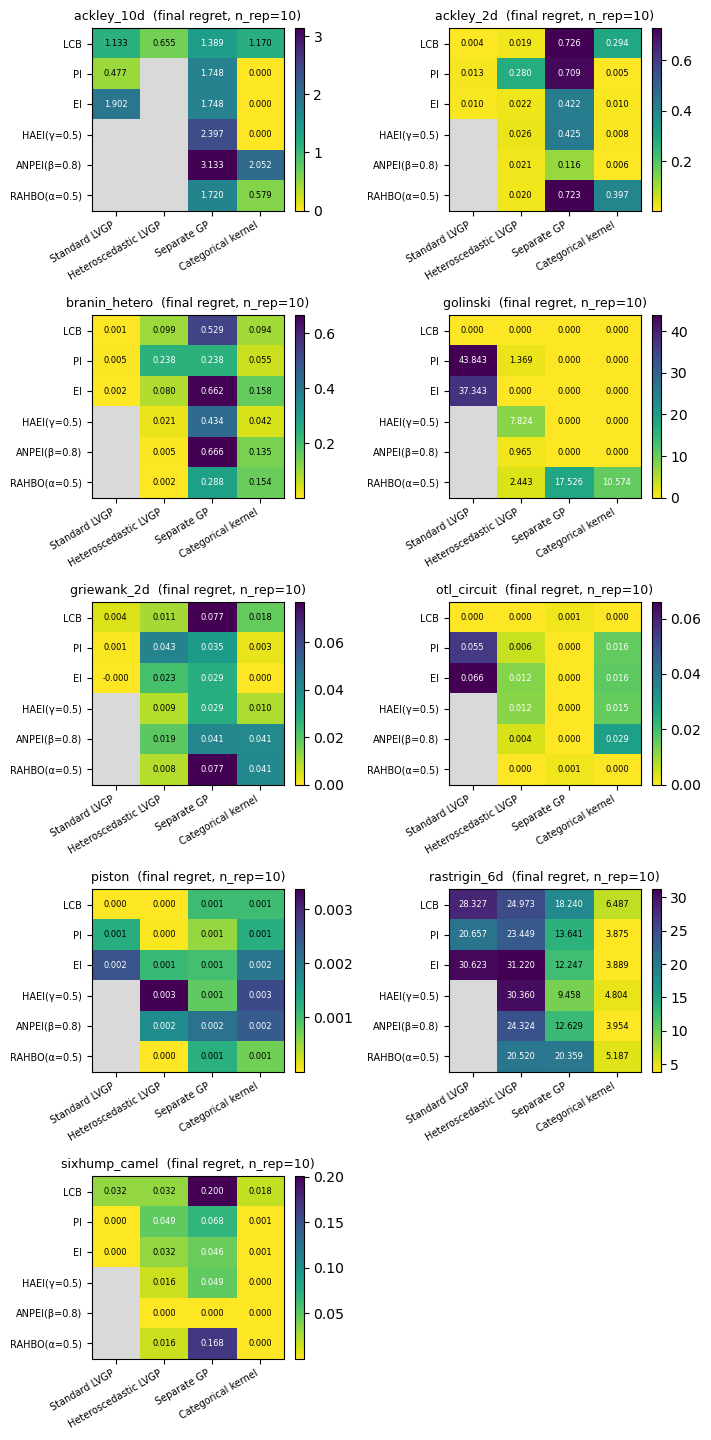

In [5]:
from utils.results import heatmaps_by_function
heatmaps_by_function(grid, functions=FUNCS, n_rep=N_REP, ground_truth=True, ncol=2);

In [6]:
# conclusive ranking: mean rank across problems, two fair angles in one table
# (bestacq = each model at its own best acquisition; blind = shared ei/lcb/pi only; lower = better)
rk = method_ranking(grid, functions=DONE, n_rep=N_REP)
style_best(rk, directions={c: ("max" if "win" in c else "min") for c in rk.columns})

,mean_rank_bestacq,wins_bestacq,mean_rank_blind,usual_best_acq
model,,,,
Standard LVGP,1.830000,4,2.110000,LCB
Categorical kernel,2.170000,1,2.060000,LCB
Heteroscedastic LVGP,2.500000,0,2.720000,RAHBO(α=0.5)
Separate GP,3.500000,1,3.110000,ANPEI(β=0.8)


> **📌 Observations (§3).**
> 1. The MATLAB LVGPs post the lowest raw regrets on the easy 1-D problems — but see the engine
>    caveat above: part of that edge is the loop, not the model (it shows up even for non-LVGP
>    models when run through the MATLAB loop).
> 2. Regret separates models weakly on the 1-D problems (every method finds the optimum region;
>    differences are exploitation-precision, magnified by the log axis). The multi-dim problems
>    (golinski, otl, piston, rastrigin) are where regret is informative.
> 3. Treat §3 as "can it find good designs at all" — the discriminating questions (model quality,
>    robustness) are answered in §4–§5.

## §4 — Model quality (loop-free: scores the *model*, not the loop)

Computed from the stored posterior at the incumbent recommendation (`mu, s, r` at `X_min_est`,
last 25 iterations) against the TRUE $f$ and $\sigma^2$ — no BO-loop confound, no re-running.

| metric | equation | reads as | target |
|---|---|---|---|
| MAE | $\overline{\lvert\mu - f\rvert}$ | surface accuracy at the point that matters | low |
| RRMSE | $\sqrt{\overline{(\mu-f)^2}}\,/\,\mathrm{std}(f_{\text{sampled}})$ | relative accuracy, cross-problem comparable | low |
| cov90 | $\overline{\mathbb{1}[\lvert\mu-f\rvert \le 1.645\,s]}$ | **calibration** of the 90% interval | ≈ 0.90 |
| IS90 | interval width $+\ \tfrac{2}{0.1}\cdot$ miss distances, normalized | accuracy + calibration in one (Gneiting) | low |
| nMAE | $\overline{\lvert r - \sigma^2\rvert}\,/\,\overline{\sigma^2}$ | **noise capture** (NaN for noise-blind) | low |

cov90 ≪ 0.9 = overconfident (intervals miss the truth); cov90 ≈ 1.0 = underconfident (too wide).
First table: the 3 noise-blind acqs all four models share (apples-to-apples); rank table aggregates
(cov90 ranked by $\lvert\text{cov90} - 0.9\rvert$).

In [7]:
mq = model_quality_table(grid, functions=DONE, n_rep=N_REP, acqs=("ei","lcb","pi"))
display(style_best(mq, directions={"MAE":"min","RRMSE":"min","IS90":"min","nMAE":"min","cov90":"max"},
                   group_level="problem"))
rk = model_quality_ranks(mq)
style_best(rk, directions={c:"min" for c in rk.columns})

,MAE,RRMSE,cov90,IS90,nMAE,mean_rank
model,,,,,,
Categorical kernel,1.333333,1.333333,2.166667,1.166667,2.166667,1.633333
Separate GP,2.166667,2.166667,1.916667,2.166667,1.333333,1.950000
Heteroscedastic LVGP,2.833333,2.666667,1.916667,2.666667,2.500000,2.516667
Standard LVGP,3.666667,3.833333,4.000000,4.000000,nan,3.875000


> **📌 Observations (§4).**
> 1. **The heteroscedastic treatment is what fixes calibration** — Standard LVGP (noise-blind) is
>    drastically overconfident (cov90 ≈ 0.02–0.30: its 90% intervals miss the truth 70–98% of the
>    time), because it fits replicate means as if they were noiseless. Heteroscedastic LVGP restores
>    cov90 ≈ 0.9–1.0. This is the designed-for win, and it is unambiguous in the data.
> 2. **Raw accuracy is led by the simple Categorical-kernel GP** (best mean rank), with
>    Separate GP and Heter LVGP close behind — the LVGP's latent structure does not buy extra
>    surface accuracy on these problems; its value is calibration (§4) and robustness (§5).
> 3. Standard LVGP ranks last on essentially every model-quality metric — being noise-blind hurts
>    the *model* even when the loop still finds good samples (§3).

## §5 — Robustness: what does each model actually RECOMMEND?

The deliverable of noisy BO is the **final recommended design** $x_{\text{rec}}$ — scored here on
the TRUE $f$ and $\sigma^2$, three complementary ways (noise-aware acquisitions HAEI/ANPEI/RAHBO —
the regime these methods were built for):

**(a) Pareto (hyperparameter-free).** A design is *dominated* if another design is both better AND
quieter. Recommendations **on** the ground-truth front are optimal for *some* risk weight; ones
up-right of it are indefensible at ANY α. Every MV-α picks a point on this front, so one picture
subsumes the α-sweep.

**(b) Percentiles (unit-free).** `f_pct` = % of ALL designs with lower true f (0 = recommended the
best design that exists); `sigma2_pct` = % of all designs that are quieter. Reads as
*"top x% performance, quietest y%"*.

**(c) MV + α-sensitivity.** $\mathrm{MV}_\alpha$ of the recommendation (median over seeds), and
whether the acquisition ranking survives α ∈ {1, 5, 15} — the check that conclusions aren't an
artifact of one risk weight.

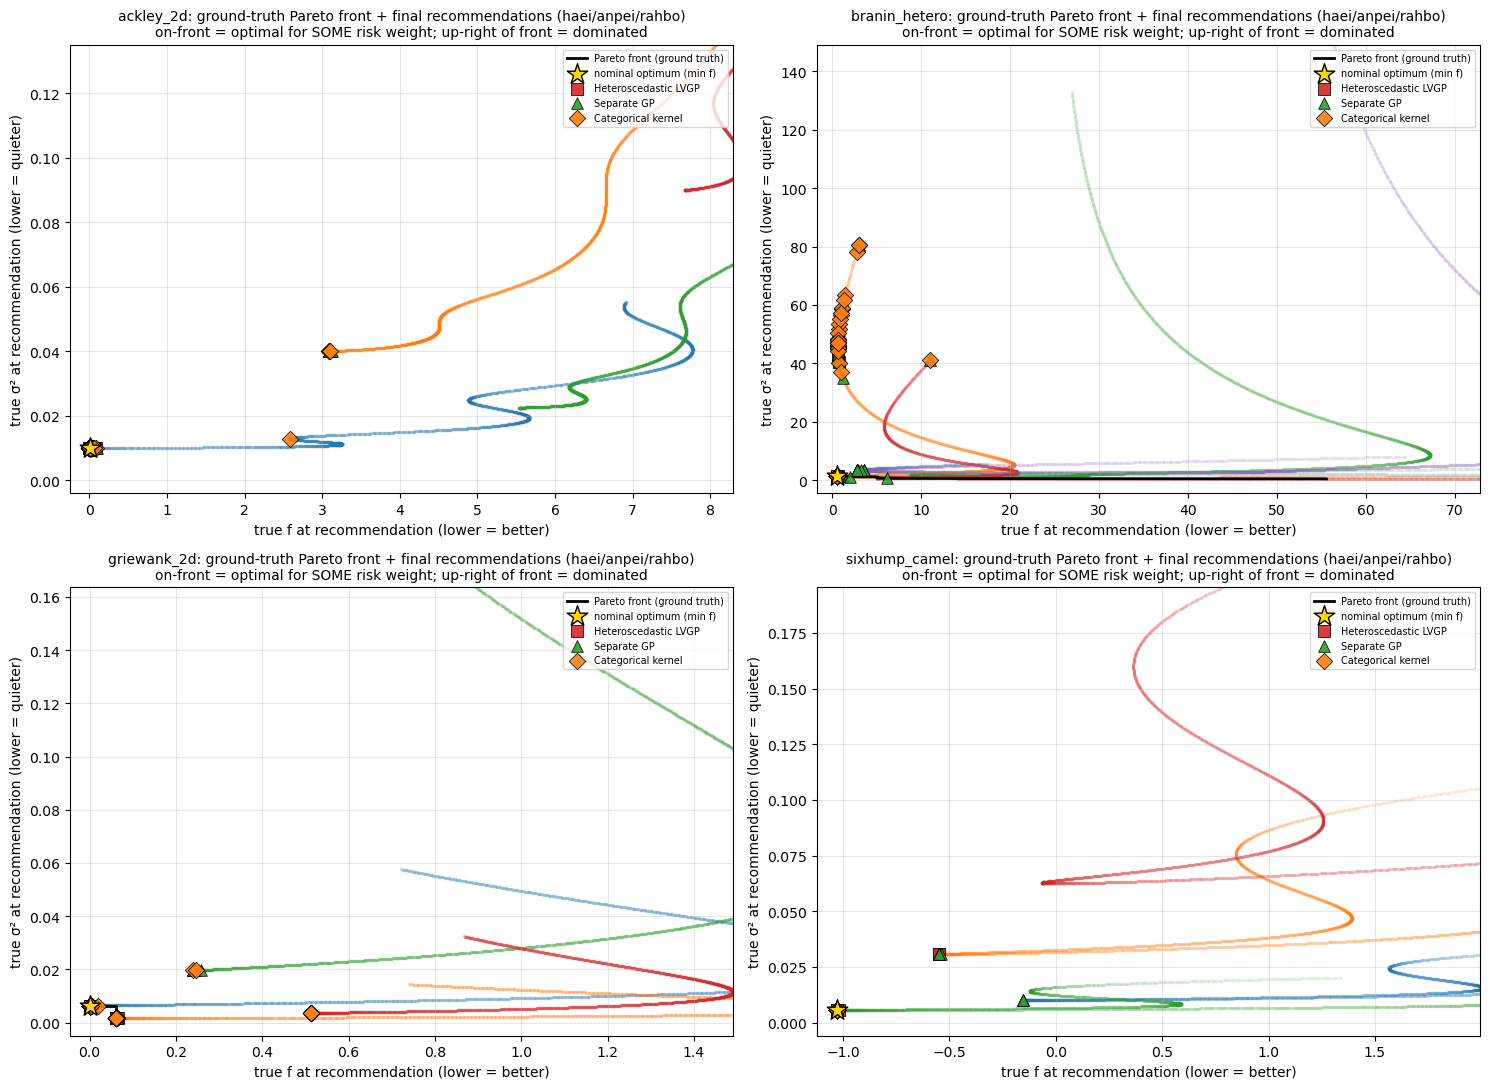

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11), squeeze=False)
for ax, fn in zip(axes.ravel(), ONE_D):
    pareto_plot(grid, fn, n_rep=N_REP, acqs=("haei","anpei","rahbo"), ax=ax)
for k in range(len(ONE_D), 4): axes.ravel()[k].axis("off")
plt.tight_layout(); plt.show()

**MV convergence** — the robustness analogue of the regret plot: running best of
$\mathrm{MV}_\alpha = f + \alpha\sigma^2$ over sampled designs, minus the true MV optimum
(shown for RAHBO, the robustness-designed acquisition; $\alpha=1$).

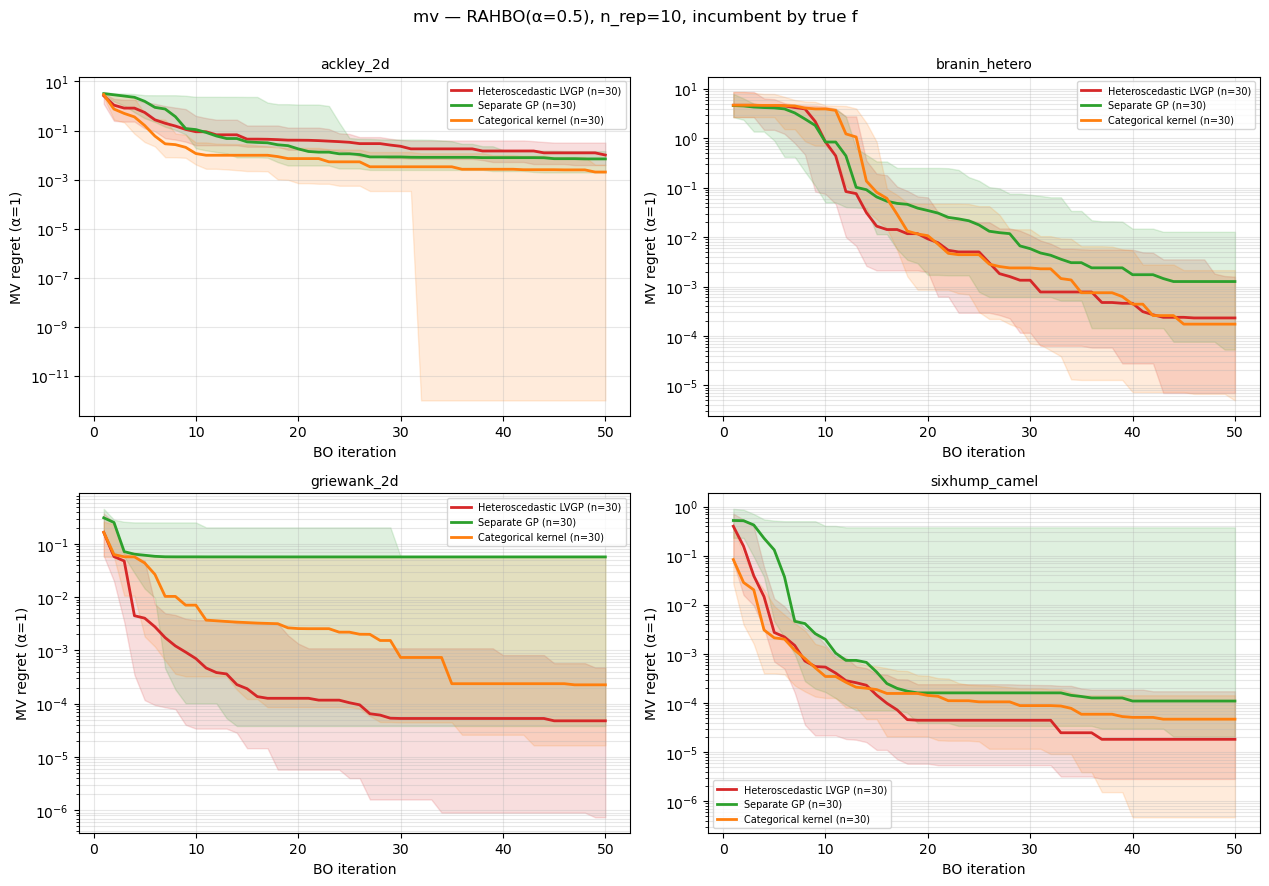

In [9]:
from utils.results import facet
facet(grid, "mv", functions=ONE_D, acf="rahbo", param=0.5, n_rep=N_REP, center="median");

In [10]:
pf = percentile_framing(grid, functions=DONE, n_rep=N_REP, acqs=("haei","anpei","rahbo"))
display(style_best(pf, directions={"f_pct":"min","sigma2_pct":"min"}, group_level="problem"))
rob = design_robustness_table(grid, functions=DONE, n_rep=N_REP, acqs=("haei","anpei","rahbo"))
style_best(rob, group_level="problem")

In [11]:
pp, acq_rank_by_alpha = mv_alpha_sweep(grid, functions=DONE, alphas=(1,5,15), n_rep=N_REP)
print("acquisition mean rank by MV-alpha (does the robustness verdict survive the risk weight?)")
style_best(acq_rank_by_alpha, directions={c:"min" for c in acq_rank_by_alpha.columns})

acquisition mean rank by MV-alpha (does the robustness verdict survive the risk weight?)


alpha,1,5,15
acquisition,,,
ANPEI(β=0.8),3.110000,2.830000,2.390000
EI,3.440000,3.170000,3.330000
HAEI(γ=0.5),3.110000,3.060000,3.000000
LCB,3.830000,4.610000,4.720000
PI,3.940000,3.940000,4.000000
RAHBO(α=0.5),3.560000,3.390000,3.560000


> **📌 Observations (§5).**
> 1. **The branin trap catches the Categorical-kernel GP**: a cluster of its noise-aware
>    recommendations sits at σ² ≈ 40–80 (the lower-but-noisy twin, x≈9.4) — *dominated* designs,
>    indefensible at any risk weight — while Heter LVGP and Separate GP recommendations sit on the
>    front near the quiet optimum.
> 2. **Same-performance, quieter designs from Heter LVGP**: on otl_circuit all models reach top-0%
>    f, but Heter LVGP recommends from the **quietest 11%** of the design space vs **34%** for both
>    python GPs — the clearest single robustness number in the study so far.
> 3. On median MV (noise-aware acqs), Heter LVGP leads (≈0.952), narrowly over Categorical (≈0.955)
>    and Separate GP (≈1.004) — consistent with 1–2 but small; the Pareto/percentile views carry
>    more evidence than this single scalar.
> 4. Remember §2.4: the sweep's α=0.5 sits below every trap threshold — robustness differences show
>    up *despite* the mild risk weight, which strengthens rather than weakens the conclusion.

## §6 — Cost

Mean wall-clock per cell (one full BO run) from each cell's stored runtime. Same-machine numbers
(all four models ran on vision); a small accuracy edge may not justify an order of magnitude more
compute — and the MATLAB LVGPs are the expensive ones.

In [12]:
runtime_table(grid)

model,Categorical kernel,Heteroscedastic LVGP,Separate GP,Standard LVGP
function,,,,
ackley_10d,11586.6,77938.4,4102.0,76766.6
ackley_2d,73.4,410.9,18.8,396.5
branin_hetero,113.8,750.3,44.5,676.4
golinski,2587.1,24925.1,1712.1,26264.9
griewank_2d,54.2,312.7,17.7,312.6
otl_circuit,3998.9,16472.4,1181.8,15570.6
piston,5347.5,21692.2,2351.1,18683.7
rastrigin_6d,6601.9,17541.8,1575.4,18042.1
sixhump_camel,58.2,312.9,20.5,305.3


> **📌 Observation (§6).** The MATLAB LVGPs cost ~10–25× the python GP models per cell
> (hours vs minutes at 200 iterations). The validated native python LVGP port (see
> `compare_matlab_python.ipynb`) closes most of that gap (~4× faster per iteration than MATLAB on
> the same machine, ~12–25× on a dedicated node) — relevant for the pending 10-D block.

## §7 — Verdict (as of the current data)

**What we can conclude now:**
1. **Heteroscedastic modeling earns its complexity in uncertainty and robustness, not raw accuracy.**
   Calibration: cov90 ≈ 0.9–1.0 vs the noise-blind Standard LVGP's 0.02–0.30 (§4). Robust
   recommendations: quietest-11% vs 34% designs at equal f on otl (§5.2); on-front recommendations
   where the Categorical GP gets trapped on branin (§5.1); best median MV (§5.3).
2. **If you only care about raw surface accuracy on these problems, the simple Categorical-kernel GP
   is the best buy** (§4.2) — but it is exactly the model the robustness trap catches (§5.1), the
   sharpest illustration that accuracy and robustness are different competencies.
3. **Standard LVGP is dominated as a *model*** — last on quality metrics, overconfident, and its
   good regret numbers carry the engine-loop caveat (§3).
4. **The benchmark design works**: the trap problems (branin/griewank/golinski) discriminate,
   the control problems (camel/ackley) confirm no method is penalized when robustness is free (§2).

**What we cannot conclude yet:**
- Multi-dim robustness (piston, rastrigin still filling; 10-D pending) — the trap problems so far
  are 1-D, where every model finds the optimum region; higher dimensions may reshuffle §4/§5.
- Cross-engine regret superiority (the loop confound; §3) — use the loop-free §4 metrics instead.
- Statistical strength: 5 seeds ⇒ medians/ranks and cross-problem consistency, not per-problem
  significance. The full 30-seed evidence exists only on the four 1-D problems.

**Watch next:** piston + rastrigin completing (adds two multi-dim rows to every §4/§5 table), and
the 10-D scope decision (native python LVGP makes it tractable if adopted).